<a href="https://colab.research.google.com/github/walperju/GoogleCollab/blob/main/RamdomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd #tratar dados tabulares , ou seja em linhas e colunas
import numpy as np #tratar dados na forma de vetores e matrizes , muito usado para AI
from sklearn.model_selection import train_test_split #usado para dividir em conjunto de treino e conjunto de testes
from sklearn.ensemble import RandomForestClassifier #usada para criar o modelo , que no momento é o Em Grupo - ensemble(RandomForest)
from sklearn.preprocessing import LabelEncoder #usado para codificar os dados, transformar os dados categoricos em numericos para que as bibliotcas sejam capazes de compreender e processar.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report #contem as metricas usadas para calcular a regressao linear
from yellowbrick.classifier import ConfusionMatrix #usada para gerar a matriz de confusao em classificacoes
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt #para gerar o objeto
from sklearn.tree import plot_tree #para exibir o objeto


In [2]:
base = pd.read_csv("insurance.csv", keep_default_na=False)
base.head()

,Unnamed: 0,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,1,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,2,False,Senior,Prole,Cautious,Current,None,Football,None,Economy,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,3,False,Senior,UpperMiddle,Psychopath,Current,None,Football,None,FamilySedan,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,4,False,Adolescent,Middle,Normal,Older,None,EggShell,None,Economy,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,5,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [3]:
base = base.drop(columns=['Unnamed: 0'])
base.head()

,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,Poor,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,False,Senior,Prole,Cautious,Current,None,Football,None,Economy,Normal,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,False,Senior,UpperMiddle,Psychopath,Current,None,Football,None,FamilySedan,Excellent,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,False,Adolescent,Middle,Normal,Older,None,EggShell,None,Economy,Normal,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,Poor,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [4]:
Y=base.iloc[:,7].values #coluna acidente que será a nossa classe , portanto y
X=base.drop(base.columns[7], axis=1).values
X

array([[False, 'Adult', 'Prole', ..., False, 'Thousand', 'Many'],
       [False, 'Senior', 'Prole', ..., True, 'Thousand', 'Zero'],
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'One'],
       ...,
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero']],
      dtype=object)

In [5]:
labelencoder = LabelEncoder() #transforma a variavel independente CATEGORICA em uma variavel independente DISCRETA
for i in range(X.shape[1]):
  if X[:,i].dtype == 'object':
    X[:,i] = labelencoder.fit_transform(X[:,i])
X

array([[0, 1, 1, ..., 0, 3, 0],
       [0, 2, 1, ..., 1, 3, 2],
       [0, 2, 2, ..., 1, 3, 1],
       ...,
       [0, 2, 2, ..., 1, 3, 2],
       [0, 1, 0, ..., 1, 3, 2],
       [0, 1, 0, ..., 1, 3, 2]], dtype=object)

In [6]:

X_treinamento, X_test, Y_treinamento, Y_test = train_test_split(X, Y,test_size=0.3, random_state=12) #dividindo os dados em treino e teste

In [7]:
modelo  = RandomForestClassifier(random_state=1, max_depth=20, max_leaf_nodes=12, n_estimators=500)#randomState , maxDepth= max vertical,profundidade ;max_leaf_node=max horizontal , numero de folhas , n_estimators= qtas arvore de decisao serão induzidas
modelo.fit(X_treinamento, Y_treinamento)

RandomForestClassifier(max_depth=20, max_leaf_nodes=12, n_estimators=500,
                       random_state=1)

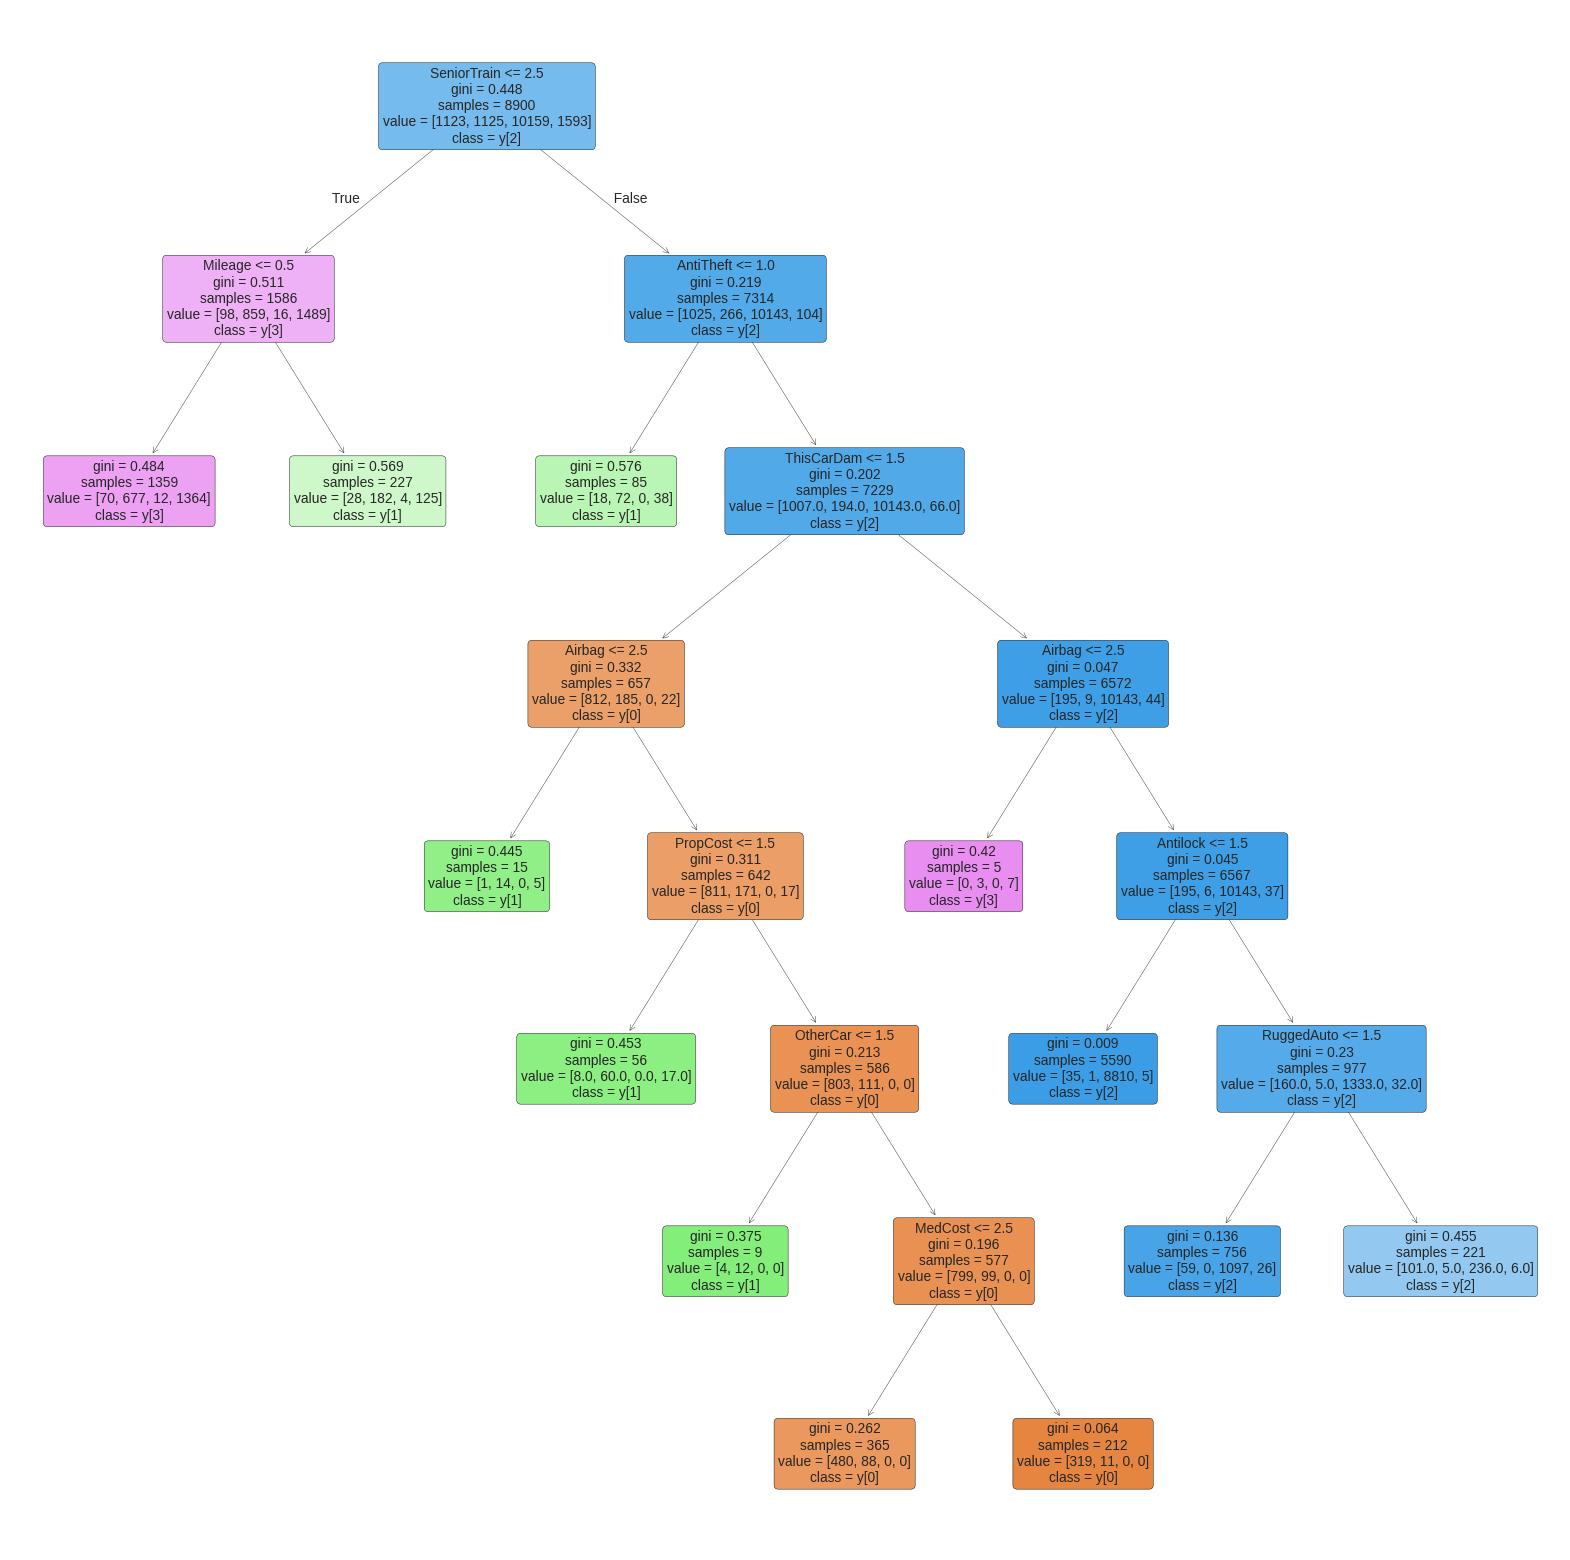

In [8]:
tree_index = 0 #variavel de controle
tree_to_visualize = modelo.estimators_[tree_index] #estamos visualizando a arvore 0, conforme parametrizamos na variavel de controle
plt.figure(figsize=(20, 20)) #tamanho da imagem que iremos criar
plot_tree(tree_to_visualize, filled=True, feature_names=base.columns[:-1], class_names=True, rounded=True)
plt.show()

In [9]:
previsoes = modelo.predict(X_test) #sempre que usar scikitLearn use o método predict

In [10]:
accuracy = accuracy_score(Y_test, previsoes) #simplesmente o percentual de acerto
precision = precision_score(Y_test, previsoes, average='weighted')
recall = recall_score(Y_test, previsoes, average='weighted')
f1 = f1_score(Y_test, previsoes, average='weighted')
print(f'Acurácia:{accuracy},Precisão:{precision},Recall:{recall},F1_Score:{f1}')

Acurácia:0.9296666666666666,Precisão:0.9264995089298133,Recall:0.9296666666666666,F1_Score:0.9252184168338298


In [11]:
report = classification_report(Y_test, previsoes) #metodo para sumarizar e dispor mais amigavelmente as métricas geradas pelo modelo.
print(report)

              precision    recall  f1-score   support

        Mild       0.88      0.61      0.72       570
    Moderate       0.76      0.69      0.72       488
        None       0.96      1.00      0.98      4253
      Severe       0.87      0.93      0.90       689

    accuracy                           0.93      6000
   macro avg       0.87      0.81      0.83      6000
weighted avg       0.93      0.93      0.93      6000

